In [1]:
import csv
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

ROUNDS_FILE = "results/report/rounds_old.csv"
OUT_DIR = "results/report"

BLUE, ORANGE, INK, GRID = "#2a78d6", "#eb6834", "#333333", "#dddddd"
VARIANTS = [("v1", "PPO v1"), ("no_coin_rule", "PPO v2\nno coin rule"), ("full", "PPO v2\n(final)")]
PANELS = [("4p", "Four players (vs. 3 rule-based)", 25), ("duel", "Duel (vs. 1 rule-based)", 50)]

In [2]:
rounds = defaultdict(list)
with open(ROUNDS_FILE) as f:
    for row in csv.DictReader(f):
        rounds[row["config"]].append(row)


def column(config, key):
    return np.array([float(r[key]) for r in rounds[config]])

In [3]:
def style(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0, colors=INK)


plt.rcParams.update({"font.size": 10, "text.color": INK, "axes.labelcolor": INK})
labels = [label for _, label in VARIANTS]
x = np.arange(len(VARIANTS))

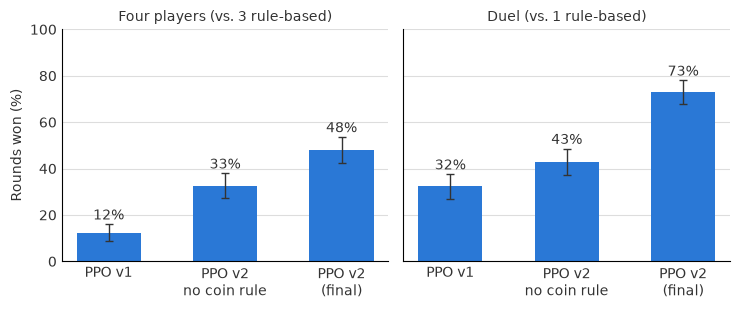

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.2), sharey=True)
for ax, (prefix, title, chance) in zip(axes, PANELS):
    wins = [column(f"{prefix}_{v}", "win") for v, _ in VARIANTS]
    rate = [100 * w.mean() for w in wins]
    ci = [100 * 1.96 * w.std(ddof=1) / np.sqrt(len(w)) for w in wins]
    ax.bar(x, rate, width=0.55, color=BLUE, yerr=ci, capsize=3,
           error_kw=dict(ecolor=INK, linewidth=1))
    for xi, r, c in zip(x, rate, ci):
        ax.text(xi, r + c + 2, f"{r:.0f}%", ha="center")
    ax.set_xticks(x, labels)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, 100)
    style(ax)
axes[0].set_ylabel("Rounds won (%)")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/fig_win_rate.pdf")
fig.savefig(f"{OUT_DIR}/fig_win_rate.png", dpi=200)

Text(0, 0.5, 'Points per round')

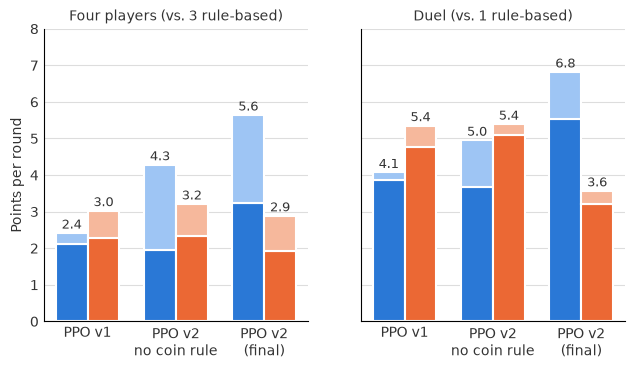

In [8]:
LIGHT_BLUE, LIGHT_ORANGE = "#9ec5f4", "#f6b89c"
SERIES = [(-0.18, "coins", "kills", BLUE, LIGHT_BLUE, "PPO agent"),
          (0.18, "opp_coins", "opp_kills", ORANGE, LIGHT_ORANGE, "Rule-based agent")]

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.8), sharey=True)
w = 0.36
for ax, (prefix, title, _) in zip(axes, PANELS):
    for offset, coin_key, kill_key, dark, light, name in SERIES:
        coins = np.array([column(f"{prefix}_{v}", coin_key).mean() for v, _ in VARIANTS])
        kills = np.array([5 * column(f"{prefix}_{v}", kill_key).mean() for v, _ in VARIANTS])
        ax.bar(x + offset, coins, width=w, color=dark, edgecolor="white", linewidth=1.5,
               label=f"{name}: points from coins")
        ax.bar(x + offset, kills, width=w, bottom=coins, color=light, edgecolor="white",
               linewidth=1.5, label=f"{name}: points from kills")
        for xi, total in zip(x + offset, coins + kills):
            ax.text(xi, total + 0.12, f"{total:.1f}", ha="center", fontsize=9)
    ax.set_xticks(x, labels)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, 8)
    style(ax)
axes[0].set_ylabel("Points per round")

In [ ]:
handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE),
           plt.Rectangle((0, 0), 1, 1, color=ORANGE),
           plt.Rectangle((0, 0), 1, 1, facecolor="#999999", edgecolor="white"),
           plt.Rectangle((0, 0), 1, 1, facecolor="#999999", alpha=0.45, hatch="///", edgecolor="white")]
fig.legend(handles, ["PPO agent", "Rule-based agent (mean)", "Points from coins", "Points from kills"],
           loc="lower center", ncol=4, frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0.08, 1, 1))
fig.savefig(f"{OUT_DIR}/fig_points.pdf")
fig.savefig(f"{OUT_DIR}/fig_points.png", dpi=200)